In [133]:
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt

In [134]:
# read in all words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [135]:
len(words)

32033

In [136]:
# vocabulary of characters and mappings to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [139]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:3]:
    
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix) 
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append
        
X = torch.tensor(X)
Y = torch.tensor(Y)

In [140]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([16, 3]), torch.int64, torch.Size([16]), torch.int64)

In [141]:
# create train, dev/val and test splits

def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
        
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix) 
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
C = torch.randn((27, 2))

Based on a paper titled "A neural Probabilistic Language model" by Yoshua Bengio, Réjean Ducharme, Pascal Vincent, and Christian Jauvin, the authors propose a novel approach to language modeling using neural networks. The paper introduces a probabilistic framework that leverages the power of neural networks to capture complex dependencies in natural language data.

In [ ]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [23]:
W1 = torch.randn((6, 100))
b1 = torch.randn((100))

In [25]:
# the shape of a tensor can be manipulated into required format without changing the data
emb.view(32, 6).shape

torch.Size([32, 6])

In [ ]:
# input words are embeddings - and they need to be multiplied with Weights and added to bias. And the hidden layer used is tanh. 
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # -1 is used so that pytorch will change it based on size of X. 
h.shape

torch.Size([32, 100])

In [28]:
# output Neuron
W2 = torch.randn((100, 27)) # we have 26 alphabets + '.' 
b2 = torch.randn((27))

In [29]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [30]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim= True)
prob.shape

torch.Size([32, 27])

In [33]:
# prob[1, 5] (basically - iterate over 32 rows and then pick the yth column and this Y is the index for "next character") 
prob[torch.arange(32), Y] 

tensor([1.1701e-07, 2.5084e-09, 1.2975e-06, 9.8130e-06, 4.7395e-11, 9.5124e-06,
        1.1502e-06, 6.9300e-07, 1.1435e-06, 2.9388e-10, 3.6196e-06, 6.2218e-09,
        1.1730e-06, 2.1501e-04, 1.8808e-12, 3.9349e-11, 2.1593e-09, 8.0003e-01,
        2.8770e-09, 2.9163e-02, 1.8181e-03, 1.9510e-09, 4.9096e-06, 3.5368e-09,
        7.8683e-08, 1.3664e-01, 3.3726e-05, 9.7744e-08, 9.6913e-05, 2.1203e-11,
        1.3010e-07, 9.8544e-06])

In [34]:
# take the log likelihood loss
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(14.7366)

###                          --------------------Rewritten version--------------------

In [107]:
# rewrite for readablitiy
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [142]:
g = torch.Generator().manual_seed(2147483647) 
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn((200), generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn((27), generator=g)
parameters = [C, W1, b1, W2, b2]

In [143]:
sum(p.nelement() for p in parameters) # number of parameters in the model

11897

In [144]:
for p in parameters:
    p.requires_grad = True

In [ ]:
# for data this large, it is better to use a batch size of 32.
# So we will take 32 samples at a time and then do the forward pass and backward pass.


# Also, to decide what's the best learning rate, we will do this
# lre = torch.linspace(-3, 0, 1000)
# lrs = 10**lre

lri = []
lossi = []
stepi = []


In [154]:
for i in range(50000):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,)) # 32 random integers between 0 and 32000    
    
    # forward pass
    emb = C[Xtr[ix]] # 32 x 3 x 2
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) 
    logits = h @ W2 + b2 # 32 x 27
    # counts = logits.exp() 
    # prob = counts / counts.sum(1, keepdim= True) 
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix]) # combines the above 3 steps into one function. (softmax + negative log likelihood loss)
    
    # backward pass
    for p in parameters:
        p.grad = None # set the gradients to zero before backward pass
    loss.backward()
    
    # update the parameters using gradient descent
    # lr = lrs[i] 
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad # update the parameters using gradient descent
        
#         lri.append(lre[i]) # track stats
        stepi.append(i)
        lossi.append(loss.log10().item())
# print(loss.item())

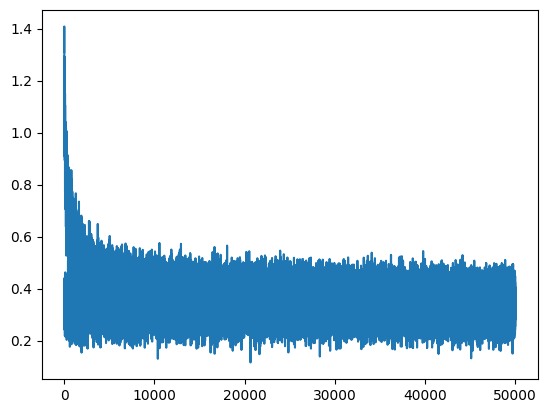

In [155]:
plt.plot(stepi, lossi)

In [156]:
emb = C[Xtr] # 228146 x 3 x 2
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) 
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Ytr)
loss # for overall data

tensor(2.1637, grad_fn=<NllLossBackward0>)

In [157]:
emb = C[Xdev] # 228146 x 3 x 2
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) 
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Ydev)
loss # for overall data

tensor(2.1914, grad_fn=<NllLossBackward0>)

We find that train and dev loss are roughly equal and that's because our NN is small. Now, we scale it further. 